<a href="https://colab.research.google.com/github/amitshara/Google-Playstore-Project/blob/main/01_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('/content/Play Store Data.csv')

In [5]:
#Data profiling
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [6]:
df.describe(include='object')

,App,Category,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,596,1695,1579,10039,10040,8714,842,326,1459,2451


In [7]:
#Missing Value handling
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [8]:
df = df.dropna()

In [9]:
#Duplicate Handling
df.duplicated().sum()

np.int64(474)

In [10]:
df = df.drop_duplicates()

In [11]:
#Cross Check DataSet
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8886 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8886 non-null   object 
 1   Category        8886 non-null   object 
 2   Rating          8886 non-null   float64
 3   Reviews         8886 non-null   object 
 4   Size            8886 non-null   object 
 5   Installs        8886 non-null   object 
 6   Type            8886 non-null   object 
 7   Price           8886 non-null   object 
 8   Content Rating  8886 non-null   object 
 9   Genres          8886 non-null   object 
 10  Last Updated    8886 non-null   object 
 11  Current Ver     8886 non-null   object 
 12  Android Ver     8886 non-null   object 
dtypes: float64(1), object(12)
memory usage: 971.9+ KB


In [12]:
#Data Type Conversion
df['Installs'] = (
    df['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')


In [13]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

In [14]:
def convert_size(size):
    size = str(size)

    if 'M' in size:
        return float(size.replace('M', ''))

    elif 'k' in size:
        return float(size.replace('k', '')) / 1024

    else:
        return None


df['Size_MB'] = df['Size'].apply(convert_size)

In [15]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

In [16]:
#Cross Check Data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8886 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             8886 non-null   object        
 1   Category        8886 non-null   object        
 2   Rating          8886 non-null   float64       
 3   Reviews         8886 non-null   int64         
 4   Size            8886 non-null   object        
 5   Installs        8886 non-null   int64         
 6   Type            8886 non-null   object        
 7   Price           8886 non-null   object        
 8   Content Rating  8886 non-null   object        
 9   Genres          8886 non-null   object        
 10  Last Updated    8886 non-null   datetime64[ns]
 11  Current Ver     8886 non-null   object        
 12  Android Ver     8886 non-null   object        
 13  Size_MB         7418 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(9)
memory

In [17]:
#Creating Filtered Data

filtered_df = df[
    (df['Rating'] >= 4.0) &
    (df['Size_MB'] >= 10) &
    (df['Last Updated'].dt.month_name() == 'January')
]


In [18]:
#Accessing Filtered DataSet
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 127 entries, 0 to 10801
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             127 non-null    object        
 1   Category        127 non-null    object        
 2   Rating          127 non-null    float64       
 3   Reviews         127 non-null    int64         
 4   Size            127 non-null    object        
 5   Installs        127 non-null    int64         
 6   Type            127 non-null    object        
 7   Price           127 non-null    object        
 8   Content Rating  127 non-null    object        
 9   Genres          127 non-null    object        
 10  Last Updated    127 non-null    datetime64[ns]
 11  Current Ver     127 non-null    object        
 12  Android Ver     127 non-null    object        
 13  Size_MB         127 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(9)
memory 

In [19]:
category_installs = (
    filtered_df.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


In [20]:
top_categories_df = filtered_df[
    filtered_df['Category'].isin(category_installs.index)
]

In [21]:
final_df = (
    top_categories_df.groupby('Category')
    .agg(
        Average_Rating=('Rating', 'mean'),
        Total_Reviews=('Reviews', 'sum')
    )
    .reset_index()
)


In [22]:
#Accessing Final Filtered and Top Category Dataset
final_df

,Category,Average_Rating,Total_Reviews
0,EDUCATION,4.400000,57645
1,ENTERTAINMENT,4.300000,869111
2,FAMILY,4.395455,4544623
3,GAME,4.313333,2397589
4,LIFESTYLE,4.380000,42809
5,PERSONALIZATION,4.475000,155996
6,PHOTOGRAPHY,4.150000,563720
7,SPORTS,4.342857,1982017
8,TOOLS,4.200000,8010
9,TRAVEL_AND_LOCAL,4.100000,974


In [23]:
from datetime import datetime
import pytz

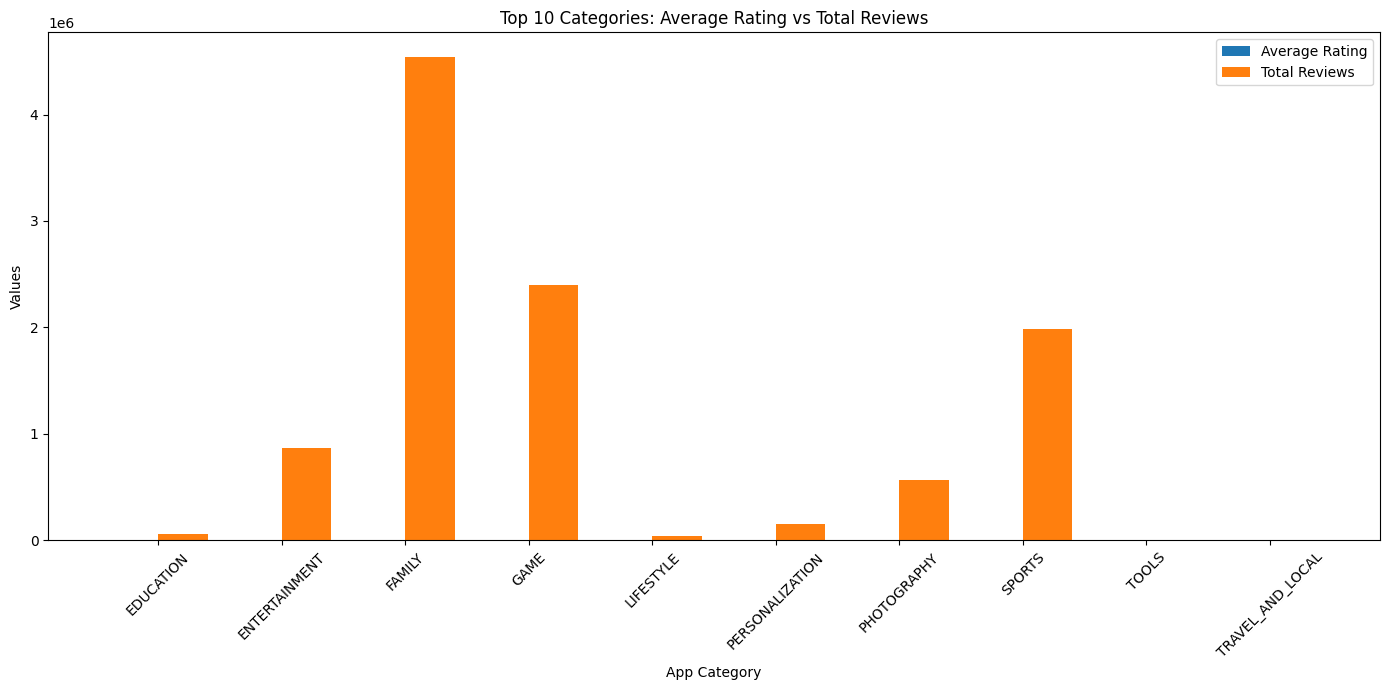

In [24]:
# =========================
# Aggregation
# =========================

final_df = (
    top_categories_df.groupby('Category')
    .agg(
        Average_Rating=('Rating', 'mean'),
        Total_Reviews=('Reviews', 'sum')
    )
    .reset_index()
)

# =========================
# Time Restriction Logic
# =========================

import pytz
from datetime import datetime
import matplotlib.pyplot as plt

ist = pytz.timezone('Asia/Kolkata')
current_time = datetime.now(ist)
current_hour = current_time.hour

if 15 <= current_hour < 18:

    # Create Figure
    fig, ax1 = plt.subplots(figsize=(14,7))

    # X-axis positions
    x = range(len(final_df))

    # Width of bars
    width = 0.4

    # Average Rating Bars
    ax1.bar(
        [i - width/2 for i in x],
        final_df['Average_Rating'],
        width=width,
        label='Average Rating'
    )

    # Total Reviews Bars
    ax1.bar(
        [i + width/2 for i in x],
        final_df['Total_Reviews'],
        width=width,
        label='Total Reviews'
    )

    # Labels
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(final_df['Category'], rotation=45)

    plt.title('Top 10 Categories: Average Rating vs Total Reviews')
    plt.xlabel('App Category')
    plt.ylabel('Values')

    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Chart is hidden. Dashboard only displays this graph between 3 PM IST and 5 PM IST.")